# Business case :

* FicZon Inc is an IT solution provider with products ranging from on premises products to SAAS based solutions. FicZon major leads generation channel is digital and through their website.FicZon business is majorly dependent on the sales force effectiveness. As the market is maturing and more new competitors entering the market, FicZon is experiencing the dip in sales. Effective sales is dependent on lead quality and as of now, this is based on manual categorization and highly depended on sales staff. Though there is a quality process, which continuously updates the lead categorization, it’s value is in for post analysis, rather than conversation.
  
* FicZon wants to explore Machine Learning to pre-categorize the lead 
quality and as result, expecting significant increase in sales 
effectiveness.

In [2]:
!pip install mysql-connector-python

In [165]:
## importing the libraries.
import os                                # importing the os for way to interact with the operating system.
import mysql.connector                   # importing the mysql.connector interaction with MySQL databases.
import pandas as pd                      # importing pandas for analyzing, cleaning, exploring, and manipulating data.
import numpy as np                       # importing numpy for mathematical operations on arrays and matrices.
import matplotlib.pyplot as plt          # importing matplotlib for create plots and graphs.
import seaborn as sns                    # importing seaborn for data visualization.
import warnings                          # we used to warnings for ignore warning messages. 
warnings.filterwarnings("ignore")

In [166]:
## Establishing a connection.
connection=mysql.connector.connect(host='18.136.157.135',
                                   user='dm_team2',
                                   password='DM!$Team&27@9!20!',
                                   database= 'project_sales',use_pure=True)

In [8]:
## connction on database.
cursor=connection.cursor() 
cursor.execute('show databases')
for i in cursor:
    print(i)

('information_schema',)
('project_sales',)


In [9]:
## show the table.
table=pd.read_sql_query('show tables',connection)
print(table)

  Tables_in_project_sales
0                    data


# Domain Analysis

In [10]:
# Retrieve data from the data table into a pandas DataFrame
data=pd.read_sql_query("select * from data",connection)
data

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
...,...,...,...,...,...,...,...,...,...
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


## <u>Attribute information</u>

* <b>Created:</b> This represents the timestamp when the product was created or the inquiry was made. It shows when the interaction happened and can be useful for trend analysis.Frequency of inquiries by date, busiest times of day, or patterns based on day/month.                                                                                                                                            
* <b>Product_ID:</b> This is the unique identifier for each product or inquiry.Count of products or inquiries for each ID to see if some products are more frequently interacted with or have more inquiries.

* <b>Source:</b> The origin of the inquiry.The Distribution of sources used by customers to inquire about products. This could help identify the most common channel for inquiries and whether some channels convert better than others.
                                                                                                                      
* <b>Mobile:</b> Indicates whether the contact was via mobile or another means.Analysis of mobile vs. non-mobile inquiries, trends in mobile usage for specific locations or products.
                                                                   
* <b>EMAIL:</b> The email associated with the inquiry.This could be analyzed to check if emails correlate with specific agents or locations. It can also be used to check for duplicates or unusual patterns.

* <b>Sales_Agent:</b> The sales agent handling the inquiry.Performance analysis of sales agents, whether specific agents are handling more cases, or whether some agents have higher conversion rates.

* <b>Location:</b> The geographical location of the inquiry or customer.Distribution of inquiries by location to understand regional trends and performance. Location-specific analysis could help in targeting or optimizing marketing efforts.

* <b>Delivery_Mode:</b> It indicates the method or mode through which an order or request is delivered.The various modes (Mode-1, Mode-2, Mode-3, etc.) might represent distinct types of delivery:<br>
      1) Mode-1 : could be Standard Delivery (e.g., regular mail or standard courier service).<br>
      2) Mode-2 : could represent Express Delivery (faster delivery, possibly at a higher cost).<br>
      3) Mode-3 : might indicate Same-day Delivery or another time-sensitive service.<br>
      4) Mode-4 or Mode-5 : could represent Premium Services, International Shipping, or more specialized delivery methods.It refer to a                                            local or in-house delivery system.
* <b>Status :</b>The current state or progress of an order, request, or customer interaction.<br>
          1) Open :- This status likely indicates that the request or order has been received, but no further action has been taken yet.The issue or                  opportunity is still being considered.<br>
          2) Potential :- This could refer to leads or requests that have the possibility to convert into actual sales or orders, but it’s not yet                    confirmed. It's in the "potential" stage, meaning there is interest but no commitment yet.<br>
          3) In Progress Positive :- This status might represent leads or orders that are actively being worked on and are progressing positively. It                 suggests that there is a high likelihood of conversion or resolution in the customer's favor.<br>
          4) Not Responding :- This could mean the customer has not responded to communications or follow-ups. It indicates that the business has                     reached out but has not received any replies or engagement from the customer.<br>
          5) Just Enquiry :- The request or lead has been categorized as an inquiry, where the customer is asking for information but has not yet made a               purchase or firm commitment. It's at the initial stage of interest.<br>
          6) Junk Lead :- This refers to leads that are unlikely to convert into a sale. These could be irrelevant, fake, or otherwise deemed unworthy                of further effort or resources. It might also be used for leads that don't meet the target customer criteria.<br>
          7) Converted :- This indicates that a lead or request has successfully converted into a sale or a completed action.The conversion has been                   achieved, and it’s now considered a closed deal.<br>
          8) In Progress Negative :- This status likely represents situations where progress is being made but the outcome is not favorable.<br>
          9) LOST :- A request or lead that has been abandoned or is no longer viable. The opportunity has been lost, and the customer is no longer                   moving forward with the purchase or interaction.<br>
          10)Long Term :- This status might be used for leads or requests that are not immediately actionable, but the opportunity is being kept for                  follow-up at a later date.<br>
          11)converted :- This indicates that the lead or request has successfully turned into a completed sale, deal, or resolved order.

In [11]:
#find duplicate value
data.duplicated().sum()

2

In [12]:
# remove duplicate value
data.drop_duplicates(inplace=True)

In [13]:
data.Created

0       14-11-2018 10:05
1       14-11-2018 09:22
2       14-11-2018 09:21
3       14-11-2018 08:46
4       14-11-2018 07:34
              ...       
7417    28-04-2018 09:45
7418    28-04-2018 09:43
7419    28-04-2018 09:20
7420    28-04-2018 08:04
7421    28-04-2018 07:54
Name: Created, Length: 7420, dtype: object

# Basic Check

In [14]:
## It show first five rows of the dataset.
data.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,,Mode-5,Open
1,14-11-2018 09:22,,Website,XXXXXXX,#VALUE!,Sales-Agent-10,,Mode-5,Open
2,14-11-2018 09:21,,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,,Mode-5,Open
3,14-11-2018 08:46,,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open
4,14-11-2018 07:34,,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,,Mode-5,Open


In [15]:
## It show last five rows of the dataset.
data.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9,Call,,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15,Call,,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5,Live Chat-Direct,,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21,CRM form,,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25,Website,,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [16]:
# Display summary information about the DataFrame.
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7420 entries, 0 to 7421
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Created        7420 non-null   object
 1   Product_ID     7420 non-null   object
 2   Source         7420 non-null   object
 3   Mobile         7420 non-null   object
 4   EMAIL          7420 non-null   object
 5   Sales_Agent    7420 non-null   object
 6   Location       7420 non-null   object
 7   Delivery_Mode  7420 non-null   object
 8   Status         7420 non-null   object
dtypes: object(9)
memory usage: 579.7+ KB


* Here, It gives no null value or missing value in dataframe.

In [17]:
## It show the statistical information of data.
data.describe()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
count,7420,7420,7420,7420,7420,7420,7420,7420,7420
unique,6752,30,26,487,883,13,18,5,11
top,26-09-2018 11:30,18,Call,,#VALUE!,Sales-Agent-4,Other Locations,Mode-5,Junk Lead
freq,4,1711,2547,1810,1699,1500,2500,2973,1536


* Product_ID 18 is the most frequently occurring product.
* Call is the most common lead source.
* Sales-Agent-4 is the most active sales agent.
* Mode-5 is the most used delivery mode.

# Exploratory Data Analysis

<b> Exploratory Data Analysis (EDA) </b> :- EDA is a process of analyzing and visulalizing data. It involves summarizing the datasets key characteristics, identifying patterns, spotting anomalies, checking assumptions.
* There are three type of EDA :-<br>
        1)Univariate Analysis<br>
        2)Bivariate Analysis<br>
        3)Multivariate Analysis

### Step 1 : Univariate Analysis

In [18]:
## Analyze and summarize a single variable

Text(-3.9305555555555554, 0.5, '')

<Figure size 1000x1500 with 0 Axes>

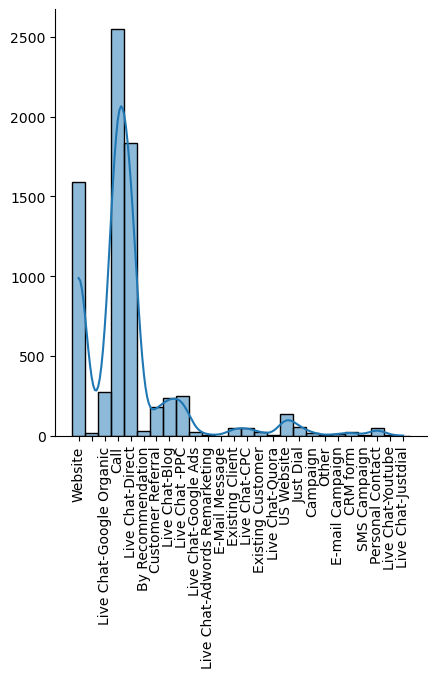

In [19]:
# Analyszing Source column
plt.figure(figsize=(10, 15))         # Adjust figure size as needed
sns.displot(x=data.Source,kde=True)  # Create displot with KDE
plt.xticks(rotation=90)              # Rotate the x-axis tick labels by 90 degrees for better visibility and readability.
plt.xlabel('',fontsize=10)           # X-axis label
plt.ylabel('',fontsize=10)           # Y-axis label

* Here,we can say that

Text(-3.9305555555555554, 0.5, '')

<Figure size 1000x1500 with 0 Axes>

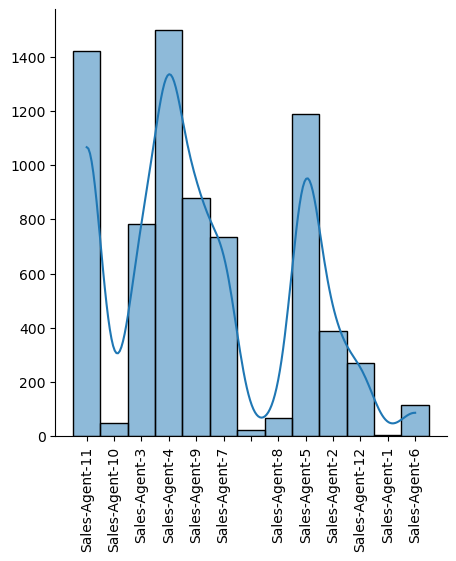

In [20]:
# Analyszing Sales_Agent column
plt.figure(figsize=(10, 15))              # Adjust figure size as needed
sns.displot(x=data.Sales_Agent,kde=True)  # Create displot with KDE
plt.xticks(rotation=90)                   # Rotate the x-axis tick labels by 90 degrees for better visibility and readability.
plt.xlabel('',fontsize=10)                # X-axis label
plt.ylabel('',fontsize=10)                # Y-axis label

* Here,we can say that sales-agent-11 having the highest number of loans and sales-agent-6 having the lowest.

Text(-3.9305555555555554, 0.5, '')

<Figure size 1000x1500 with 0 Axes>

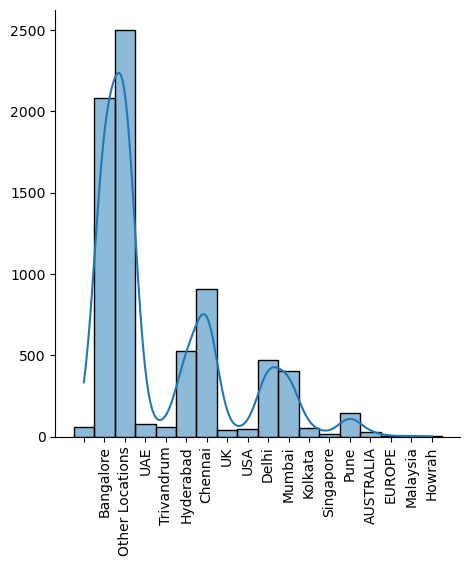

In [21]:
# Analyszing Location column
plt.figure(figsize=(10, 15))              # Adjust figure size as needed
sns.displot(x=data.Location,kde=True)     # Create displot with KDE
plt.xticks(rotation=90)                   # Rotate the x-axis tick labels by 90 degrees for better visibility and readability.
plt.xlabel('',fontsize=10)                # X-axis label
plt.ylabel('',fontsize=10)                # Y-axis label

* Here,we can say that location banglorre having the highest sales.

Text(-3.9305555555555554, 0.5, '')

<Figure size 1000x1500 with 0 Axes>

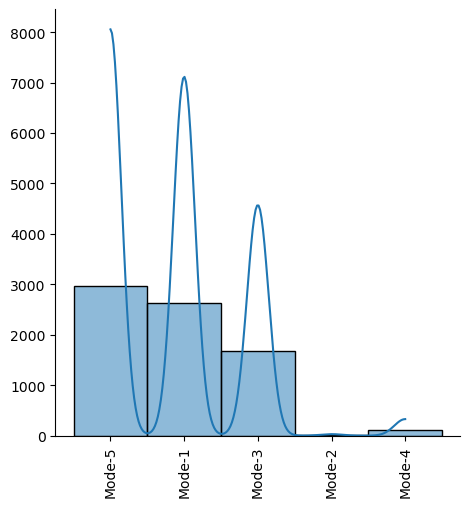

In [22]:
# Analyszing Delivery_Mode column
plt.figure(figsize=(10, 15))                 # Adjust figure size as needed
sns.displot(x=data.Delivery_Mode,kde=True)   # Create displot with KDE
plt.xticks(rotation=90)                      # Rotate the x-axis tick labels by 90 degrees for better visibility and readability.
plt.xlabel('',fontsize=10)                   # X-axis label
plt.ylabel('',fontsize=10)                   # Y-axis label

* Here,we can say that the Mode-5 being the most frequent,followed by Mode-3 and Mode-2. Mode-4 has the least frequency.

Text(-3.9305555555555554, 0.5, '')

<Figure size 1000x1500 with 0 Axes>

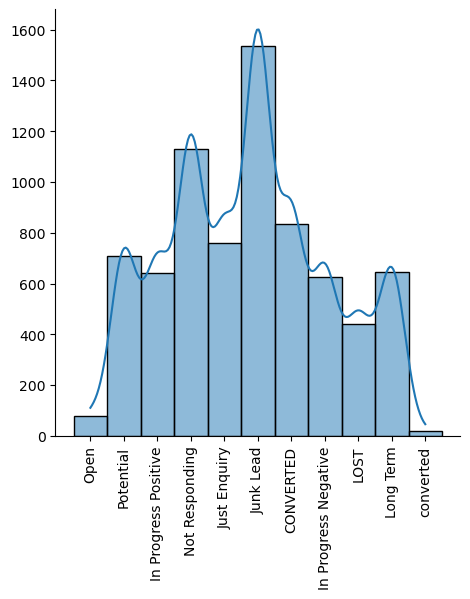

In [23]:
# Analyszing Status column
plt.figure(figsize=(10, 15))                 # Adjust figure size as needed
sns.displot(x=data.Status,kde=True)          # Create displot with KDE
plt.xticks(rotation=90)                      # Rotate the x-axis tick labels by 90 degrees for better visibility and readability.
plt.xlabel('',fontsize=10)                   # X-axis label
plt.ylabel('',fontsize=10)                   # Y-axis label

* Here,we can say that the stage with the highest number of leads is "Potential" followed by "In Progress Positive" and "Open".

### Step 2 : Bivariate Analysis

In [24]:
## Bivariate Analysis refers to plots between input variables and target variable.Analyze the relationship between two variables.

In [25]:
## Here, we can not use of Bivariate Analysis because all columns are categorical.Therefore,the relationship between two columns will not be analysis.

### Step 3 Multivariate Analysizing

In [26]:
## Analyze the relationship in all columns.
## Here, we can not use of multivariate analysis because all columns are categorical.

### Report of EDA :

* Product_ID 18 is the most frequently occurring product.
* Call is the most common lead source.
* Sales-Agent-4 is the most active sales agent.
* Mode-5 is the most used delivery mode.  

# Feature Engineering

* Feature engineering is the process of using domain knowledge to select, modify, or create new features (variables) from raw data that make machine learning models more effective.
* Create new features from existing ones to improve the model’s performance.

## I) Data Preprocessing 
* <b>Data Preprocessing :</b> It is  cleaning, transforming, and organizing the data into a suitable structure.

<b><u>Handling Missing Value :</u></b> Missing or incomplete data can distort statistical analyses and models.

In [27]:
## step 1: Handling the missing values.
data.isnull().sum()
# here,we are not given null value but null is being displayed in the dataframe,so we have to find the null value and remove it.  

Created          0
Product_ID       0
Source           0
Mobile           0
EMAIL            0
Sales_Agent      0
Location         0
Delivery_Mode    0
Status           0
dtype: int64

In [28]:
# This is handling missing or invalid values represented by empty or blank strings.
data['Product_ID']=data['Product_ID'].replace([""," "],np.nan)

In [29]:
#The .isnull().sum() function counts number of NaN values in 'Product_ID' column after the replacement
print("Number of Nan value:",data['Product_ID'].isnull().sum())

Number of Nan value: 56


In [30]:
# This is handling missing or invalid values represented by empty or blank strings.
data['Source']=data['Source'].replace([""," "],np.nan)

In [31]:
#The .isnull().sum() function counts number of NaN values in 'Source' column after the replacement
print("Number of Nan value:",data['Source'].isnull().sum())

Number of Nan value: 17


In [32]:
# This is handling missing or invalid values represented by empty or blank strings.
data['Location']=data['Location'].replace([""," "],np.nan)

In [33]:
#The .isnull().sum() function counts number of NaN values in 'Location' column after the replacement
print("Number of Nan value:",data['Location'].isnull().sum())

Number of Nan value: 56


In [34]:
# This is handling missing or invalid values represented by empty or blank strings.
data['Mobile']=data['Mobile'].replace([""," "],np.nan)

In [35]:
#The .isnull().sum() function counts number of NaN values in 'Mobile' column after the replacement
print("Number of Nan value:",data['Mobile'].isnull().sum())

Number of Nan value: 1810


In [36]:
# This is handling missing or invalid values represented by empty or blank strings.
data['Sales_Agent']=data['Sales_Agent'].replace([""," "],np.nan)

In [37]:
#The .isnull().sum() function counts number of NaN values in 'Sales_Agent' column after the replacement
print("Number of Nan value:",data['Sales_Agent'].isnull().sum())

Number of Nan value: 23


In [38]:
# This is handling missing or invalid values represented by empty or blank strings.
data['EMAIL']=data['EMAIL'].replace([""," "],np.nan)

In [39]:
#The .isnull().sum() function counts number of NaN values in 'EMAIL' column after the replacement
print("Number of Nan value:",data['EMAIL'].isnull().sum())

Number of Nan value: 0


In [40]:
# find null value
data.isnull().sum()

Created             0
Product_ID         56
Source             17
Mobile           1810
EMAIL               0
Sales_Agent        23
Location           56
Delivery_Mode       0
Status              0
dtype: int64

### Source :

In [41]:
## Count the frequency of each unique value in the 'Source' column.
data.Source.value_counts()

Source
Call                             2547
Live Chat-Direct                 1834
Website                          1592
Live Chat-Google Organic          274
Live Chat -PPC                    249
Live Chat-Blog                    237
Customer Referral                 180
US Website                        137
Just Dial                          56
Existing Client                    51
Personal Contact                   50
Live Chat-CPC                      50
By Recommendation                  32
CRM form                           23
Existing Customer                  22
Live Chat-Google Ads               21
Campaign                           19
E-mail Campaign                    12
Live Chat-Adwords Remarketing       7
Live Chat-Quora                     2
Other                               2
SMS Campaign                        2
Live Chat-Youtube                   2
E-Mail Message                      1
Live Chat-Justdial                  1
Name: count, dtype: int64

### Product_ID :

In [42]:
## Count the frequency of each unique value in the 'Product_ID' column.
data.Product_ID.value_counts()

Product_ID
18    1711
15    1518
19    1189
9      992
27     739
5      487
10     168
1      105
20     102
25      90
21      66
2       38
12      36
26      31
14      27
11      12
22       8
3        7
17       7
6        7
8        6
13       5
24       3
16       3
23       2
0        2
28       1
7        1
4        1
Name: count, dtype: int64

### Mobile :

In [43]:
data.EMAIL.value_counts()

EMAIL
#VALUE!               1699
sXXXXXXX@gmail.com     781
aXXXXXXX@gmail.com     445
rXXXXXXX@gmail.com     342
mXXXXXXX@gmail.com     305
                      ... 
dXXXXXXXwal@bt.com       1
uXXXXXXXectric.com       1
dXXXXXXX9@gmail.co       1
pXXXXXXXamaris.com       1
mXXXXXXXengira.com       1
Name: count, Length: 883, dtype: int64

In [44]:
## Count the frequency of each unique value in the 'Mobile' column.
data.Mobile.value_counts()

Mobile
XXXXXXX       220
988XXXXXXX    211
984XXXXXXX    177
998XXXXXXX    125
994XXXXXXX    112
             ... 
747XXXXXXX      1
124XXXXXXX      1
031XXXXXXX      1
(31XXXXXXX      1
9535207621      1
Name: count, Length: 486, dtype: int64

### Sales_Agent :

In [45]:
## Count the frequency of each unique value in the 'Sales_Agent' column.
data.Sales_Agent.value_counts()

Sales_Agent
Sales-Agent-4     1500
Sales-Agent-11    1420
Sales-Agent-5     1190
Sales-Agent-9      879
Sales-Agent-3      781
Sales-Agent-7      736
Sales-Agent-2      389
Sales-Agent-12     269
Sales-Agent-6      114
Sales-Agent-8       68
Sales-Agent-10      47
Sales-Agent-1        4
Name: count, dtype: int64

### Location :

In [46]:
## Count the frequency of each unique value in the 'Location' column.
data.Location.value_counts()

Location
Other Locations    2500
Bangalore          2084
Chennai             909
Hyderabad           528
Delhi               471
Mumbai              402
Pune                142
UAE                  79
Trivandrum           58
Kolkata              55
USA                  45
UK                   41
AUSTRALIA            25
Singapore            17
Malaysia              4
EUROPE                3
Howrah                1
Name: count, dtype: int64

In [47]:
## Remove null value in Product_ID column.
data.loc[data["Product_ID"].isnull(),"Product_ID"] = 18       # here we are imputing missing value using 18.

In [48]:
## Remove null value in Source column.
data.loc[data["Source"].isnull(),"Source"] = "Call"           # here we are imputing missing value using 'call'.

In [49]:
## Remove null value in Mobile column.
data.loc[data["Mobile"].isnull(),"Mobile"] = "Unknown"        # here we are imputing missing value using 'Unknown'.

In [50]:
## Remove null value in Sales_Agent column.
data.loc[data["Sales_Agent"].isnull(),"Sales_Agent"] = "Sales-Agent-4" # here we are imputing missing value using 'Sales-Agent-4'.

In [51]:
## Remove null value in Location column.
data.loc[data["Location"].isnull(),"Location"] = "Other Locations"     # here we are imputing missing value using 'Other Locations'.

In [52]:
data.drop(columns=['Product_ID','EMAIL','Mobile'],axis=1,inplace=True)

In [53]:
data

,Created,Source,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,Website,Sales-Agent-11,Other Locations,Mode-5,Open
1,14-11-2018 09:22,Website,Sales-Agent-10,Other Locations,Mode-5,Open
2,14-11-2018 09:21,Website,Sales-Agent-10,Other Locations,Mode-5,Open
3,14-11-2018 08:46,Website,Sales-Agent-10,Other Locations,Mode-5,Open
4,14-11-2018 07:34,Website,Sales-Agent-10,Other Locations,Mode-5,Open
...,...,...,...,...,...,...
7417,28-04-2018 09:45,Call,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,Call,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,Live Chat-Direct,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,CRM form,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry


 <b><u> Encoding Categorical Variables :</u></b> Categorical variables need to be transformed into numerical formats for machine learning models.
 * Label Encoding
 * One-Hot Encoding
 * Ordinal Encoding

In [54]:
## step 2 :Convert to categorical data to numerical data.

In [55]:
# importing OneHotEncoder from preprocessing
from sklearn.preprocessing import OneHotEncoder
OHE=pd.get_dummies(data.Delivery_Mode,dtype=int,prefix="Delivery")
# Here we are apply OneHot Encoding on Delivery_Mode features and store in OHE variable.

In [56]:
# Here we are merging of Delivery_Mode column and data into data. Now, we don't need thal features we will drop.
data=pd.concat([data,OHE],axis=1) 

In [57]:
data.drop(columns=['Delivery_Mode'],axis=1,inplace=True)   # drop Delivery_Mode column

In [58]:
# importing LabelEncoder from preprocessing
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()                                # Initialize the LabelEncoder

# List of columns to encode
label_encoder=['Source','Sales_Agent','Location','Status']

In [59]:
# Apply LabelEncoder to each column in the list
for column in label_encoder:
            data[column]=label.fit_transform(data[column])

In [60]:
## importing datetime
import datetime

# Convert the 'Created' column to a datetime object
data['Created'] = pd.to_datetime(data['Created'], format='%d-%m-%Y %H:%M')

# Extract numerical features
data['year'] = data['Created'].dt.year
data['month'] = data['Created'].dt.month
data['day'] = data['Created'].dt.day
data['hour'] = data['Created'].dt.hour
data['minute'] = data['Created'].dt.minute
data['weekday'] = data['Created'].dt.weekday  

In [61]:
#drop column of created
data.drop(columns=['Created'],axis=1,inplace=True)   # drop Delivery_Mode column

<b><u>Handling Outliers :</u></b> Outliers can significantly impact the performance of machine learning models.

In [62]:
df = data[["Source","day","minute"]]  # here we are storing continous features in data

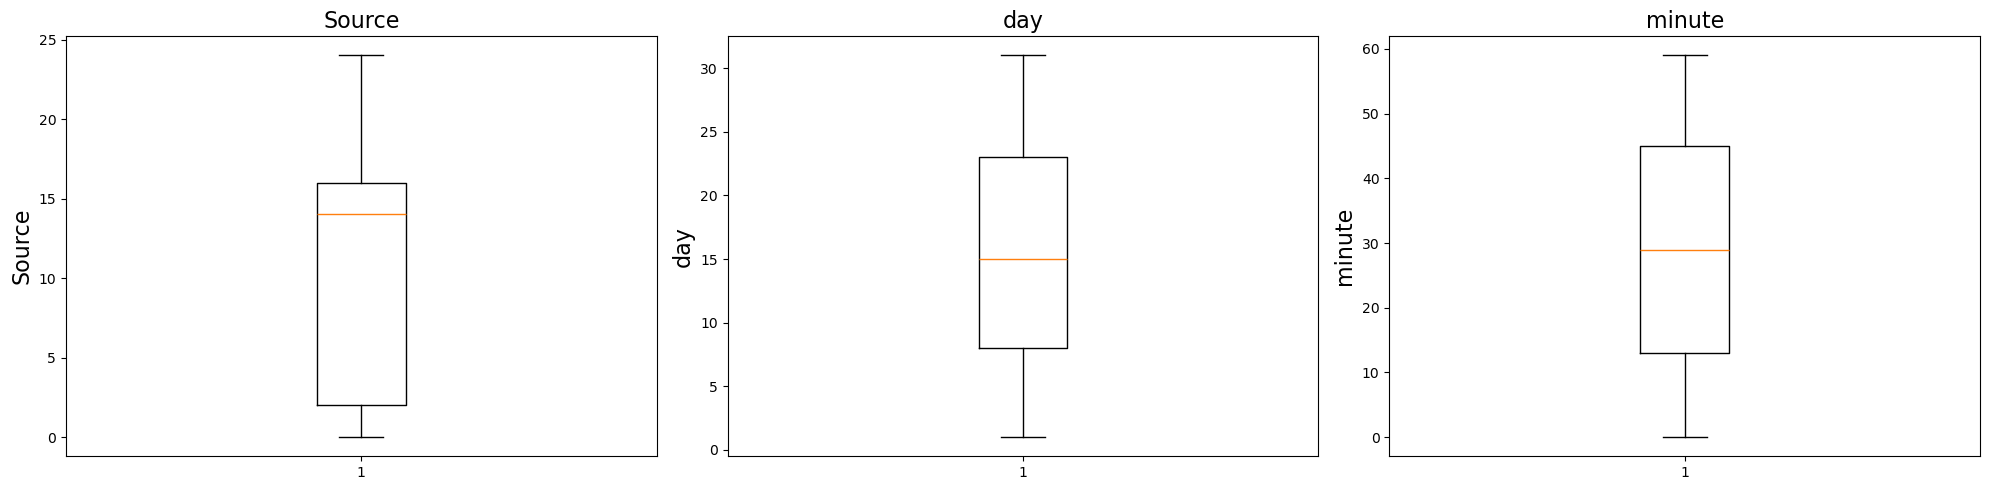

In [63]:
# here we are running a for loop for plot boxplot for all continous features.
plt.figure(figsize=(20,5))                          #define a figure size
plot_num = 1

# Creating the boxplot with customized flier points
flierprops = dict(marker='*', markerfacecolor='blue', markersize=8) 

for i in df:
    if plot_num <= 3:
        plt.subplot(1,3,plot_num)                   #create rows and column grid in 1x3
        plt.boxplot(df[i],flierprops=flierprops)    # Creating the boxplot using of check outliers with flier 
        plt.title(i, fontsize=16)                   # show title
        plt.ylabel(i, fontsize=16)                  # y-axis label
        plot_num += 1
plt.tight_layout()         # show the data

* Here,we can not show any outlier in this graph.

<u><b> Scalling :</u></b> Scaling is very important of continous features because some model give more priproty to that features which has higest values campare to another features. that's why we use Scaling to make all values into certain ranges.scaling technique can significantly improve the efficiency and accuracy of your model.It help improve the performance and accuracy of machine learning models.

* It is technique to convert all data into certain range.<br><br>
* <b>The types of scalling are : </b><br> 
     <b>1) Min-Max Scaling :</b> Min-Max scaling transforms the data to a specific range, usually between 0 and 1. The values are rescaled according to the minimum and maximum values of the feature.<br>
     <b>2) Standardization : </b>- Standardization Scaling transform all data between -3 to +3 range. it use z-score to tranform data.

In [64]:
## step 4 : feature scaling
from sklearn.preprocessing import StandardScaler    #importing StandardScaler from preprocessing
standard = StandardScaler()                           # Define the StandardScaler object)

In [65]:
data.head(5)

,Source,Sales_Agent,Location,Status,Delivery_Mode-1,Delivery_Mode-2,Delivery_Mode-3,Delivery_Mode-4,Delivery_Mode-5,year,month,day,hour,minute,weekday
0,24,2,10,8,0,0,0,0,1,2018,11,14,10,5,2
1,24,1,10,8,0,0,0,0,1,2018,11,14,9,22,2
2,24,1,10,8,0,0,0,0,1,2018,11,14,9,21,2
3,24,1,10,8,0,0,0,0,1,2018,11,14,8,46,2
4,24,1,10,8,0,0,0,0,1,2018,11,14,7,34,2


In [66]:
# here we are taking all columns where we have to apply scaling.
sc = ['Source', 'Sales_Agent', 'Location', 'Status','year','month','day', 'hour','minute','weekday']  

In [67]:
# here we are applying Standard Scaling
data1=standard.fit_transform(data[sc])

In [68]:
data1

array([[ 1.45151247e+00, -1.40456158e+00,  9.80496087e-01, ...,
        -8.21576136e-01, -1.36520012e+00, -2.01846085e-01],
       [ 1.45151247e+00, -1.75584401e+00,  9.80496087e-01, ...,
        -1.06822183e+00, -3.82578848e-01, -2.01846085e-01],
       [ 1.45151247e+00, -1.75584401e+00,  9.80496087e-01, ...,
        -1.06822183e+00, -4.40380099e-01, -2.01846085e-01],
       ...,
       [ 2.81065108e-01, -1.40456158e+00, -1.12191621e+00, ...,
        -1.06822183e+00, -4.98181350e-01,  1.43617573e+00],
       [-1.24051646e+00,  5.68111737e-04,  9.80496087e-01, ...,
        -1.31486752e+00, -1.42300137e+00,  1.43617573e+00],
       [ 1.45151247e+00, -3.50714312e-01, -8.88314847e-01, ...,
        -1.56151321e+00,  1.46706119e+00,  1.43617573e+00]])

## II) Feature Selection

* <b>Feature selection :</b> Feature Selection is the process of relevant features from the original set of features in a dataset.The goal is to improve the performance of machine learning models by using only the most important features,which can reduce complexity,improve accuracy and speed up the training process.

In [69]:
# corrlation : identifying highly correlated fetures and removing one of them.
data.corr()  #check corrlation

,Source,Sales_Agent,Location,Status,Delivery_Mode-1,Delivery_Mode-2,Delivery_Mode-3,Delivery_Mode-4,Delivery_Mode-5,year,month,day,hour,minute,weekday
Source,1.000000,-0.030088,0.060518,0.060435,0.053348,-0.012130,0.185562,-0.072042,-0.191234,NaN,0.025905,-0.036852,0.126161,0.001348,0.112293
Sales_Agent,-0.030088,1.000000,-0.138234,-0.056708,0.193564,0.008635,0.038818,0.013530,-0.226281,NaN,0.098264,-0.007935,-0.029052,0.000674,0.001045
Location,0.060518,-0.138234,1.000000,0.097838,-0.434014,0.029597,0.157337,-0.031351,0.294733,NaN,0.069116,-0.014414,-0.078516,-0.003769,0.010575
Status,0.060435,-0.056708,0.097838,1.000000,-0.076194,-0.013492,0.033532,-0.081964,0.067915,NaN,0.127566,0.012919,0.000390,-0.002425,-0.002672
Delivery_Mode-1,0.053348,0.193564,-0.434014,-0.076194,1.000000,-0.028526,-0.401753,-0.095321,-0.605327,NaN,-0.206080,-0.037753,0.072530,0.002985,0.015981
Delivery_Mode-2,-0.012130,0.008635,0.029597,-0.013492,-0.028526,1.000000,-0.020910,-0.004961,-0.031505,NaN,0.025224,-0.010517,-0.003146,-0.000568,-0.017340
Delivery_Mode-3,0.185562,0.038818,0.157337,0.033532,-0.401753,-0.020910,1.000000,-0.069871,-0.443708,NaN,0.199104,-0.009398,0.045140,0.003073,0.030014
Delivery_Mode-4,-0.072042,0.013530,-0.031351,-0.081964,-0.095321,-0.004961,-0.069871,1.000000,-0.105275,NaN,-0.017189,0.014644,0.010222,-0.001469,0.000737
Delivery_Mode-5,-0.191234,-0.226281,0.294733,0.067915,-0.605327,-0.031505,-0.443708,-0.105275,1.000000,NaN,0.033246,0.041924,-0.111793,-0.005117,-0.040101
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

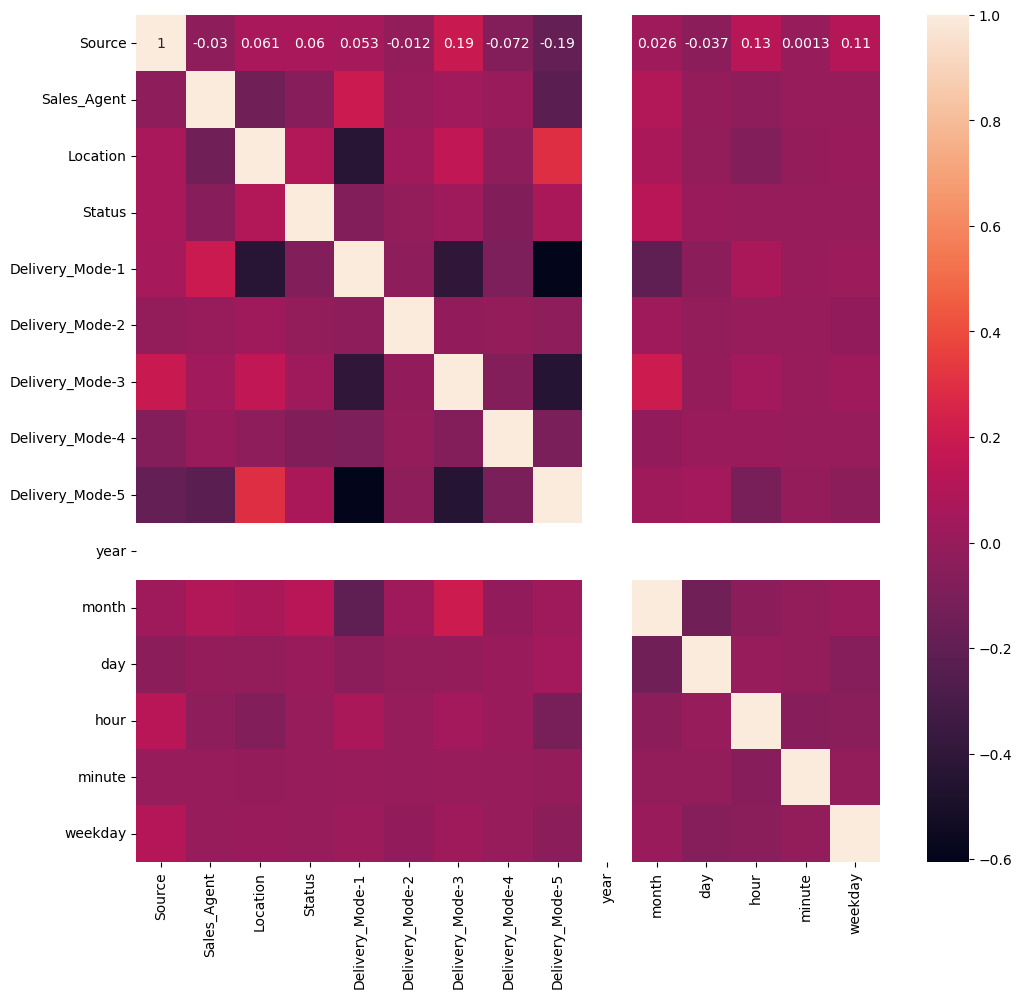

In [70]:
## We have check correlation
plt.figure(figsize=(12,11))                                #increase plot size
sns.heatmap(data.corr(),annot_kws={'size':10},annot=True)  # craete a heatmap check the relationship

* here,

# Model Creation

In [71]:
## Creating independent and dependent variable
x = data.drop(["Status"],axis=1)
y = data.Status

In [72]:
x

,Source,Sales_Agent,Location,Delivery_Mode-1,Delivery_Mode-2,Delivery_Mode-3,Delivery_Mode-4,Delivery_Mode-5,year,month,day,hour,minute,weekday
0,24,2,10,0,0,0,0,1,2018,11,14,10,5,2
1,24,1,10,0,0,0,0,1,2018,11,14,9,22,2
2,24,1,10,0,0,0,0,1,2018,11,14,9,21,2
3,24,1,10,0,0,0,0,1,2018,11,14,8,46,2
4,24,1,10,0,0,0,0,1,2018,11,14,7,34,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7417,2,8,9,0,0,0,1,0,2018,4,28,9,45,5
7418,2,3,10,0,0,0,0,1,2018,4,28,9,43,5
7419,14,2,1,1,0,0,0,0,2018,4,28,9,20,5
7420,1,6,10,1,0,0,0,0,2018,4,28,8,4,5


In [73]:
y

0       8
1       8
2       8
3       8
4       8
       ..
7417    5
7418    5
7419    7
7420    4
7421    0
Name: Status, Length: 7420, dtype: int32

### PCA

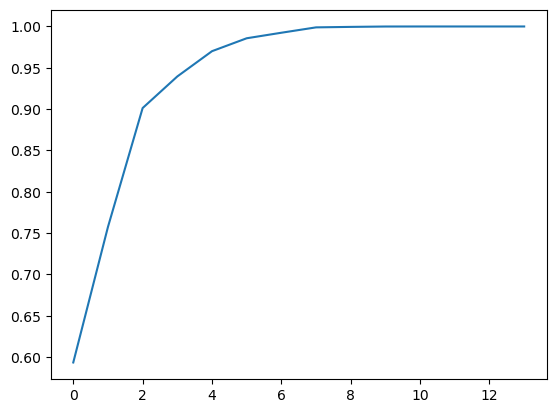

In [74]:
from sklearn.decomposition import PCA              #import the PCA class from sklearn.decomposition
pca = PCA()                                        #create an instance of PCA
principle_components = pca.fit_transform(x)        #fit the PCA model to the data
plt.plot(np.cumsum(pca.explained_variance_ratio_)) #plot the cumulative sum of the explained variance ratio
plt.show()                                         #show the plot

In [75]:
np.where(np.cumsum(pca.explained_variance_ratio_)>0.90)
#Find the indices where the cumulative sum of the explained variance ratio 

(array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13], dtype=int64),)

In [76]:
pca = PCA(n_components=13)       #Initialize PCA with 13 components (reduce to 13 dimensions)
new_data = pca.fit_transform(x)  #Fit the PCA on the data 'x' and apply the dimensionality reduction
column_name = [f"principle_components {i}" for i in range(1,14)]         #Create a list of column names for the resulting principal components (PC1 to PC14)
principle_components = pd.DataFrame(data = new_data,columns=column_name) #Create a DataFrame using the transformed data (new_data) with the principal components as column names

In [77]:
principle_components

,principle_components 1,principle_components 2,principle_components 3,principle_components 4,principle_components 5,principle_components 6,principle_components 7,principle_components 8,principle_components 9,principle_components 10,principle_components 11,principle_components 12,principle_components 13
0,-23.555650,5.568344,11.141513,5.863151,2.132896,-3.062166,3.622198,-0.404679,0.438598,-0.459165,0.017099,-0.003415,7.160688e-15
1,-6.544526,5.405579,11.133732,6.328198,2.689865,-4.085670,3.756266,-0.386530,0.387313,-0.470472,0.018211,-0.003332,-2.215006e-15
2,-7.544391,5.413974,11.130684,6.332957,2.702423,-4.086846,3.754763,-0.388868,0.387095,-0.470278,0.018204,-0.003333,3.474300e-15
3,17.465793,5.183465,11.134310,6.637523,3.287485,-4.125680,3.779478,-0.370069,0.382394,-0.472902,0.018948,-0.003318,-1.932174e-15
4,5.480959,5.263569,11.025158,7.118189,4.337196,-4.208004,3.748555,-0.437788,0.369626,-0.468345,0.019410,-0.003346,-9.437880e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7415,16.318328,-14.858870,-5.536606,4.417491,1.889041,1.844320,-3.878469,2.414970,-0.253237,0.260613,1.114585,-0.026087,7.381090e-17
7416,14.316871,-14.825307,-5.452364,5.971173,0.853611,-2.901192,-3.309691,2.491421,0.297717,0.069692,-0.029928,0.001411,-1.378211e-17
7417,-8.663257,-11.213097,5.598401,-1.977561,5.719939,-5.323325,-2.852290,2.161360,-0.485955,-0.219491,-0.021136,0.003556,3.817954e-18
7418,-24.664394,-14.810894,-6.621513,6.132999,2.573467,-0.047419,-3.815523,2.333373,-0.887148,-0.460373,-0.031763,-0.001143,-3.495750e-17


In [78]:
principle_components.columns    #Get the column names of the DataFrame containing the principal components

Index(['principle_components 1', 'principle_components 2',
       'principle_components 3', 'principle_components 4',
       'principle_components 5', 'principle_components 6',
       'principle_components 7', 'principle_components 8',
       'principle_components 9', 'principle_components 10',
       'principle_components 11', 'principle_components 12',
       'principle_components 13'],
      dtype='object')

In [79]:
# Create a new DataFrame 'x1' using the standardized principal components (data1)
# Assign specific column names for each of the principal components
x1 = pd.DataFrame(data = data1,columns=['principle_components 1', 'principle_components 2',
       'principle_components 3', 'principle_components 4',
       'principle_components 5', 'principle_components 6',
       'principle_components 7', 'principle_components 8',
       'principle_components 9', 'principle_components 10',
       ])
x1    #show the DataFrame 

,principle_components 1,principle_components 2,principle_components 3,principle_components 4,principle_components 5,principle_components 6,principle_components 7,principle_components 8,principle_components 9,principle_components 10
0,1.451512,-1.404562,0.980496,1.407607,0.0,1.865419,-0.182449,-0.821576,-1.365200,-0.201846
1,1.451512,-1.755844,0.980496,1.407607,0.0,1.865419,-0.182449,-1.068222,-0.382579,-0.201846
2,1.451512,-1.755844,0.980496,1.407607,0.0,1.865419,-0.182449,-1.068222,-0.440380,-0.201846
3,1.451512,-1.755844,0.980496,1.407607,0.0,1.865419,-0.182449,-1.314868,1.004651,-0.201846
4,1.451512,-1.755844,0.980496,1.407607,0.0,1.865419,-0.182449,-1.561513,0.311036,-0.201846
...,...,...,...,...,...,...,...,...,...,...
7415,-1.123472,0.703133,0.746895,0.313146,0.0,-1.863839,1.366105,-1.068222,0.946850,1.436176
7416,-1.123472,-1.053279,0.980496,0.313146,0.0,-1.863839,1.366105,-1.068222,0.831247,1.436176
7417,0.281065,-1.404562,-1.121916,1.042786,0.0,-1.863839,1.366105,-1.068222,-0.498181,1.436176
7418,-1.240516,0.000568,0.980496,-0.051675,0.0,-1.863839,1.366105,-1.314868,-1.423001,1.436176


# Model Selection

In [102]:
# creating training and testing data
from sklearn.model_selection import train_test_split                         #import the train_test_split function from sklearn.model_selection.
x_train,x_test,y_train,y_test=train_test_split(x1,y,test_size=0.25,random_state=1)   #Split the dataset into training and testing sets

## test_size=0.25: 25% of the data will be used for testing
## random_state=1 : ensures reproducibility by fixing the seed for 1 number

In [103]:
len(x_train)  #length of X_train

5565

In [104]:
len(x_test)  #length of X_test

1855

In [105]:
y_train.value_counts()

Status
3     1124
7      880
0      632
4      575
9      539
6      481
2      466
1      451
5      343
8       62
10      12
Name: count, dtype: int64

### <u>Logistic Regreesion</u>

In [106]:
## Model Buliding 
from sklearn.linear_model import LogisticRegression   #import the LogisticRegression function from sklearn.linear_model.
logistic=LogisticRegression()          #object creation for LogisticRegression 
logistic.fit(x_train,y_train)          # training the model

LogisticRegression()

In [107]:
y_predict=logistic.predict(x_test)                # predicting the testing model

In [108]:
y_train_predict=logistic.predict(x_train)         # predicting the training model

##  Evaluation of Model

In [109]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,r2_score

In [110]:
accuracy1=accuracy_score(y_test,y_predict)     # Checking testing accuracy_score
accuracy1

0.9035040431266846

In [111]:
acc1=accuracy_score(y_train,y_train_predict)   # Checking training accuracy_score
acc1

0.9137466307277629

In [112]:
f1score1=f1_score(y_test,y_predict,average='weighted')    #checking f1_score
f1score1

0.8964340722791375

In [113]:
print(classification_report(y_test,y_predict))              

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       202
           1       0.99      0.98      0.98       175
           2       0.93      0.71      0.80       177
           3       0.87      0.99      0.92       412
           4       0.90      0.90      0.90       185
           5       0.83      0.57      0.67        97
           6       0.85      0.77      0.81       165
           7       0.84      1.00      0.91       249
           8       1.00      0.28      0.43        18
           9       0.97      1.00      0.98       169
          10       0.00      0.00      0.00         6

    accuracy                           0.90      1855
   macro avg       0.83      0.74      0.77      1855
weighted avg       0.90      0.90      0.90      1855



#### <u>Random Forest</u>

In [114]:
from sklearn.ensemble import RandomForestClassifier       # importing randomforest
random=RandomForestClassifier()                           #object creation for random forest
random.fit(x_train,y_train)                               # training the data

RandomForestClassifier()

In [115]:
y_predict2=random.predict(x_test)                 # predicting testing the model

In [116]:
y_train_predict2=random.predict(x_train)           # predicting training the model

In [117]:
accuracy2=accuracy_score(y_test,y_predict2)       # Checking testing accuracy_score
accuracy2

0.9951482479784367

In [118]:
acc2=accuracy_score(y_train,y_train_predict2)     # Checking  training accuracy_score
acc2

1.0

In [98]:
f1score2=f1_score(y_test,y_predict2,average='weighted')    # Checking F1_Score
f1score2

0.9931102295374565

#### <u>Decision Tree</u>

In [119]:
from sklearn.tree import DecisionTreeClassifier        #importing decision tree from sklearn.tree
decision=DecisionTreeClassifier()                      #object creation for decision tree
decision.fit(x_train,y_train)                          #train the model

DecisionTreeClassifier()

In [120]:
y_predict3=decision.predict(x_test)                      # predicting testing the model

In [121]:
y_train_predict3=decision.predict(x_train)               # predicting training the model

In [122]:
accuracy3=accuracy_score(y_test,y_predict3)             # Checking testing accuracy_score
accuracy3

1.0

In [123]:
acc3=accuracy_score(y_train,y_train_predict3)             # Checking  training accuracy_score
acc3

1.0

In [124]:
f1score3=f1_score(y_test,y_predict3,average='weighted')    # Checking F1_Score
f1score3

1.0

#### <u>Gradient Boosting</u>

In [125]:
from sklearn.ensemble import GradientBoostingClassifier     #importing Gradient Boosting from sklearn.ensemble
gb=GradientBoostingClassifier()                             #object creation for random forest 
gb.fit(x_train,y_train)                                     #train the model

GradientBoostingClassifier()

In [126]:
y_predict4=gb.predict(x_test)                      # predicting testing the model

In [127]:
y_train_predict4=gb.predict(x_train)               # predicting training the model

In [128]:
accuracy4=accuracy_score(y_test,y_predict4)             # Checking testing accuracy_score
accuracy4

1.0

In [129]:
acc4=accuracy_score(y_train,y_train_predict4)             # Checking  training accuracy_score
acc4

1.0

In [147]:
f1score4=f1_score(y_test,y_predict4,average='weighted')    # Checking F1_Score
f1score4

1.0

#### <u>Xrtime Gradiant Boosting</u>

In [130]:
from xgboost import XGBClassifier  #importing the model library
xgb=XGBClassifier()                # object creation
xgb.fit(x_train,y_train)           # fitting the data

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [131]:
y_predict5=xgb.predict(x_test)                      # predicting testing the model

In [132]:
y_train_predict5=xgb.predict(x_train)               # predicting trainning the model

In [133]:
accuracy5=accuracy_score(y_test,y_predict5)         # Checking testing accuracy_score
accuracy5

1.0

In [134]:
acc5=accuracy_score(y_train,y_train_predict5)             # Checking  training accuracy_score
acc5

1.0

In [135]:
f1score5=f1_score(y_test,y_predict5,average='weighted')    # Checking F1_Score
f1score5

1.0

#### <u>SVM</u>

In [136]:
from sklearn.svm import SVC
svm=SVC() 
svm.fit(x_train,y_train) 

SVC()

In [137]:
y_predict6=svm.predict(x_test)                      # predicting testing the model

In [138]:
y_train_predict6=svm.predict(x_train)               # predicting trainning the model

In [139]:
accuracy6=accuracy_score(y_test,y_predict6)         # Checking testing accuracy_score
accuracy6

0.982210242587601

In [140]:
acc6=accuracy_score(y_train,y_train_predict6)             # Checking  training accuracy_score
acc6

0.9908355795148248

In [141]:
f1score6=f1_score(y_test,y_predict6,average='weighted')    # Checking F1_Score
f1score6

0.9787065271696267

### ANN:

In [142]:
## model creation
from sklearn.neural_network import MLPClassifier
model = MLPClassifier( hidden_layer_sizes=(50,3),
                       learning_rate_init=0.1,
                       max_iter=100,
                       random_state=2) ## model object creation max_iter=Stopping parameter
model.fit(x_train,y_train) ## training the data
y_predict7 = model.predict(x_test)
y_train_predict = model.predict(x_train)

In [155]:
accuracy7=accuracy_score(y_test,y_predict7)
accuracy7

0.9929919137466308

In [157]:
acc7=accuracy_score(y_train,y_train_predict)
acc7

0.994429469901168

In [144]:
f1score7=f1_score(y_test,y_predict7,average='weighted')    # Checking F1_Score
f1score7

0.9910490097868108

In [159]:
#check the all algorithm model performance i table form.
score=pd.DataFrame({"Model":["LogisticRegression","RandomForest","DecisionTree","GradiantBoosting","XrtimeGradiantBoosting","SVM","ANN"],"accuracy_score":[accuracy1*100,accuracy2*100,accuracy3*100,accuracy4*100,accuracy5*100,accuracy6*100,accuracy7*100],"f1_score":[f1score1*100,f1score2*100,f1score3*100,f1score4*100,f1score5*100,f1score6*100,f1score7*100]})

In [160]:
score

,Model,accuracy_score,f1_score
0,LogisticRegression,90.350404,89.643407
1,RandomForest,99.514825,99.311023
2,DecisionTree,100.000000,100.000000
3,GradiantBoosting,100.000000,100.000000
4,XrtimeGradiantBoosting,100.000000,100.000000
5,SVM,98.221024,97.870653
6,ANN,99.299191,99.104901


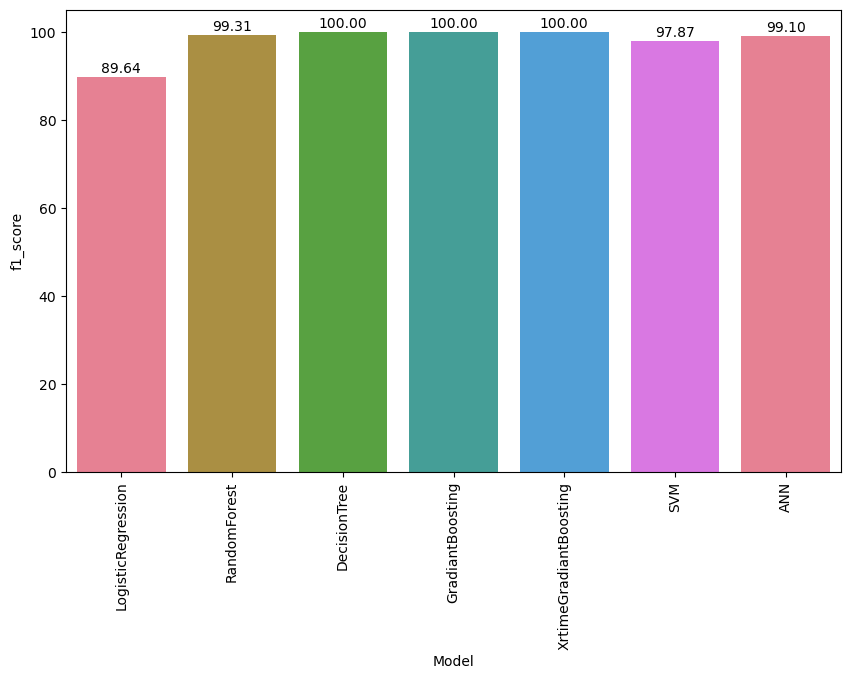

In [152]:
#use for all model performance show in barplot.
palette=sns.color_palette('husl') #define the color for bar plot.
plt.figure(figsize=(10,6)) #define the plot size.
plt.xticks(rotation=90) #show the axis value rotation.
a=sns.barplot(x=score.Model,y=score.f1_score,data=score,palette=palette) #create the barplot

for index,value in enumerate(score['f1_score']): #show individual bar values show
    a.text(index,value + 1,f'{value:.2f}',ha='center')

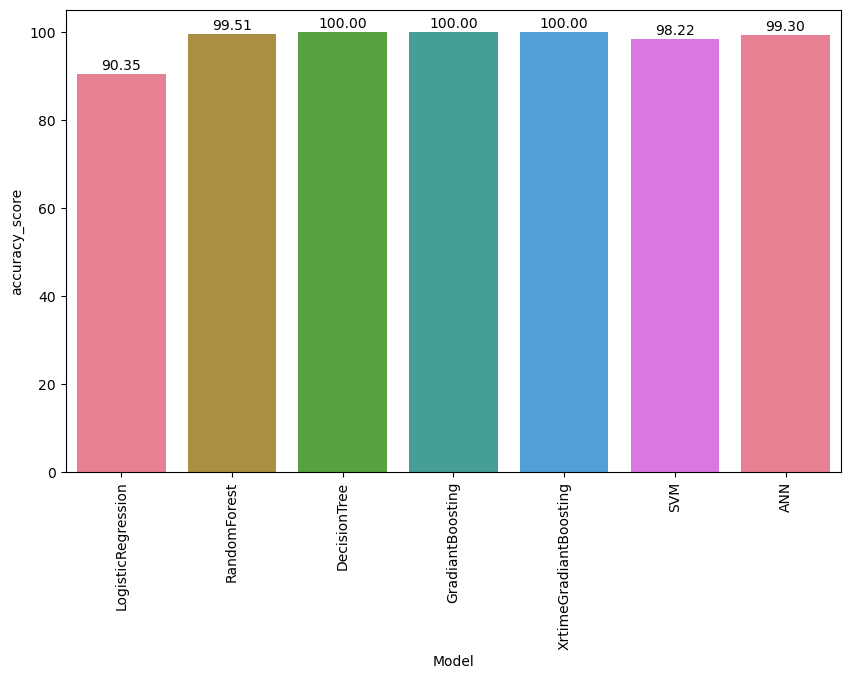

In [161]:
#use for all model performance show in barplot.
palette=sns.color_palette('husl') #define the color for bar plot.
plt.figure(figsize=(10,6)) #define the plot size.
plt.xticks(rotation=90) #show the axis value rotation.
a=sns.barplot(x=score.Model,y=score.accuracy_score,data=score,palette=palette) #create the barplot

for index,value in enumerate(score['accuracy_score']): #show individual bar values show
    a.text(index,value + 1,f'{value:.2f}',ha='center')

### HIGH POTENTIAL MODELS:


1) Random Forest : This model exhibits both high accuracy (99.51%) and high f1 score (99.31%). This combination suggests strong performance in both correctly predicting the class and minimizing fale positive/negatives.
2) Xtreme Gradient Boosting : This model also shows high accuracy (100.00%) and high f1 score (100.00%). This indicates near-perfect performance in classifying the data.
3) Gradient Boosting :  This model also shows high accuracy (100.00%) and high f1 score (100.00%).
4) ANN : With an accuracy of (99.29%) and f1 score of (99.10%), the ANN demonstrates high potential as well.
   

### LOW POTENTIAL MODELS:

1) Logistic Regression : While it has a decent accuracy of (90.35%), its f1 score is relatively lower at (89.64%).This suggest that it might have some issues with correctly classifying certain classes.
2) Decision Tree : Although it achieves (100.00%) accuracy and f1 score, its important to note hat decision trees can something overfit the training data,leading to poor generalization.

In [162]:
import pickle                            #importing pickle module.
with open("sales_effect.pkl","wb") as f:    # Open a file named "sales_effect.pkl" in write-binary ('wb') mode.   
    pickle.dump(random,f)             # Serialize the object 'random' and write it to the file.

In [163]:
with open("sales_effect.pkl","rb") as f:    # Open a file named "sales_effect.pkl" in read-binary ('rb') mode.  
    prediction=pickle.load(f)

In [164]:
prediction

RandomForestClassifier()